In [ ]:
# Exploratory Data Anlaysis
# Trader Performance Analysis Using Market Sentiments

In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
folder_name = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/data/"

In [13]:
file_name = "df_merged.csv"

In [14]:
df_merged = pd.read_csv(folder_name + file_name)

In [15]:
df_merged.head()

,account,coin,size_usd,side,timestamp_ist,direction,closed_pnl,fee,date,value,classification,sentiment_binary
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,22156.95,SELL,2024-12-03 14:39:00,Sell,3008.231185,7.754933,2024-12-03,76,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,226.43,SELL,2024-12-03 14:39:00,Sell,30.741534,0.079248,2024-12-03,76,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,302.20,SELL,2024-12-03 14:39:00,Sell,40.770089,0.105771,2024-12-03,76,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,1809.28,SELL,2024-12-03 14:39:00,Sell,243.812267,0.633248,2024-12-03,76,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,1892.21,SELL,2024-12-03 14:39:00,Sell,254.263735,0.662274,2024-12-03,76,Extreme Greed,Greed


In [16]:
df_merged.shape

(104266, 12)

In [18]:
df_daily = pd.read_csv(folder_name + "df_daily.csv")

In [20]:
print(df_daily.head())
print(df_daily.shape)

         date                                     account    daily_pnl  \
0  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -205.434737   
1  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   -24.632034   
2  2023-12-17  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   304.982785   
3  2023-12-19  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  1000.538612   
4  2023-12-20  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   162.732282   

   trade_count  avg_size_usd  total_fees  win_rate  long_ratio     net_pnl  \
0            6  12789.398333   19.184096  0.666667    0.333333 -224.618833   
1            2   5304.975000    2.652489  0.000000    1.000000  -27.284523   
2           11   5996.891818   16.491448  0.636364    0.000000  288.491337   
3           10   6188.349000   15.470867  1.000000    0.000000  985.067745   
4            8   8862.468750   17.724932  1.000000    0.000000  145.007350   

   value classification sentiment_binary  
0     72          Greed            Greed  


In [21]:
df_merged.dtypes

account              object
coin                 object
size_usd            float64
side                 object
timestamp_ist        object
direction            object
closed_pnl          float64
fee                 float64
date                 object
value                 int64
classification       object
sentiment_binary     object
dtype: object

In [22]:
df_daily.dtypes

date                 object
account              object
daily_pnl           float64
trade_count           int64
avg_size_usd        float64
total_fees          float64
win_rate            float64
long_ratio          float64
net_pnl             float64
value                 int64
classification       object
sentiment_binary     object
dtype: object

In [23]:
# Fix date columns
df_merged['date'] = pd.to_datetime(df_merged['date'])
df_daily['date']  = pd.to_datetime(df_daily['date'])

In [24]:
df_merged['timestamp_ist'] = pd.to_datetime(df_merged['timestamp_ist'])

In [25]:
print(df_merged['date'].dtype)
print(df_daily['date'].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:
#1. Univariate Analysis   → understand each column alone
#2. Bivariate Analysis    → how two columns relate
#3. Key insight charts    → answer the project questions

In [59]:
# Chart 1 : Sentiment Distribution
# How many days where Fear Vs Greed Vs Neutral?

In [30]:
charts_path = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/charts/"

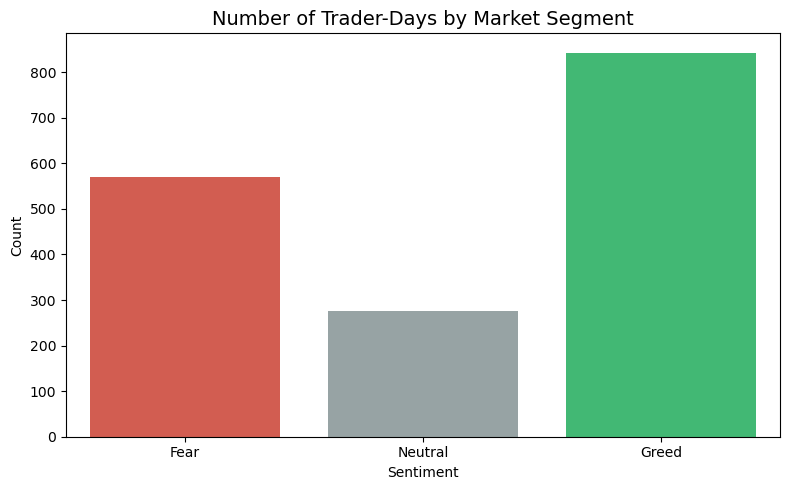

In [39]:
plt.figure(figsize = (8,5))
sns.countplot(data=df_daily, x='sentiment_binary',
              hue='sentiment_binary',
              order=['Fear', 'Neutral', 'Greed'],
              palette={'Fear': '#e74c3c', 'Neutral': '#95a5a6', 'Greed': '#2ecc71'},
              legend=False)

plt.title('Number of Trader-Days by Market Segment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(charts_path + 'chart_01_sentiment_distribution.png', dpi=150)
plt.show()

In [37]:
#Greed days:   843  ← traders were most active
#Fear days:    571  ← moderate activity  
#Neutral days: 276  ← least active

In [58]:
# Chart 2 : Average Net PnL By sentiments
# Do traders actually make more money on Fear or Greed days?

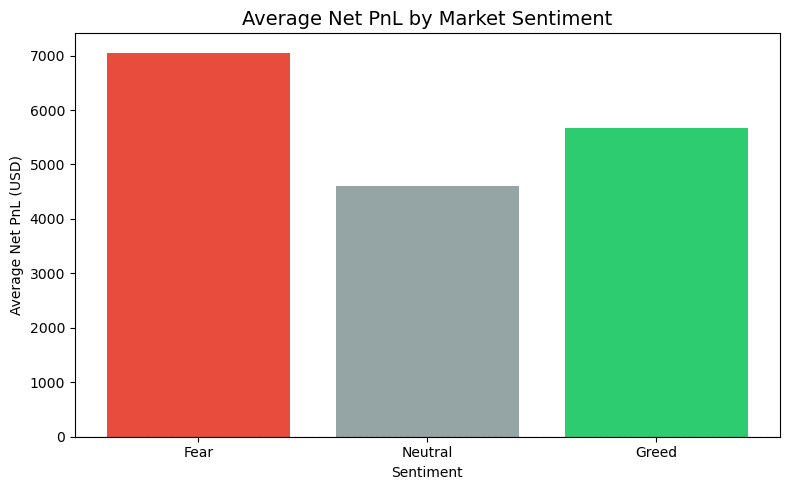

In [41]:
plt.figure(figsize = (8,5))
sentiment_pnl = df_daily.groupby('sentiment_binary')['net_pnl'].mean().reindex(['Fear','Neutral','Greed'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.bar(sentiment_pnl.index,sentiment_pnl.values, color = colors)
plt.title('Average Net PnL by Market Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Net PnL (USD)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(charts_path + 'chart_02_pnl_by_sentiment.png', dpi=150)
plt.show()

In [ ]:
# Fear days:    ~$7,000 average net PnL  ← HIGHEST!
# Greed days:   ~$5,500 average net PnL
# Neutral days: ~$4,500 average net PnL  ← LOWEST

In [60]:
# Chart # :Win rate by Sentiment

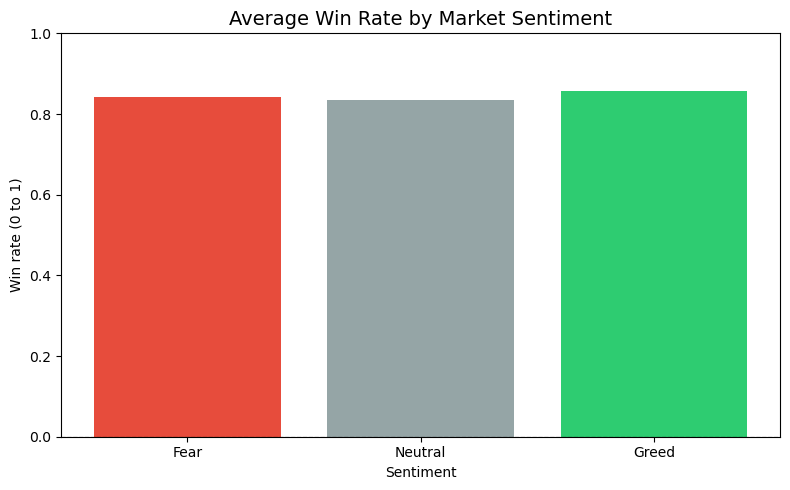

In [47]:
plt.figure(figsize =  (8,5))
sentiment_wr = df_daily.groupby('sentiment_binary')['win_rate'].mean().reindex(['Fear','Neutral','Greed'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.bar(sentiment_wr.index,sentiment_wr.values,color=colors)
plt.title('Average Win Rate by Market Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Win rate (0 to 1)')
plt.ylim(0,1)
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(charts_path + 'chart_03_winrate_by_sentiment.png', dpi=150)
plt.show()

In [46]:
print(df_daily.groupby('sentiment_binary')['win_rate'].mean().reindex(['Fear', 'Neutral', 'Greed']))

sentiment_binary
Fear       0.843219
Neutral    0.835829
Greed      0.856045
Name: win_rate, dtype: float64


In [61]:
# Chart 4 : Trade frequency by sentiment

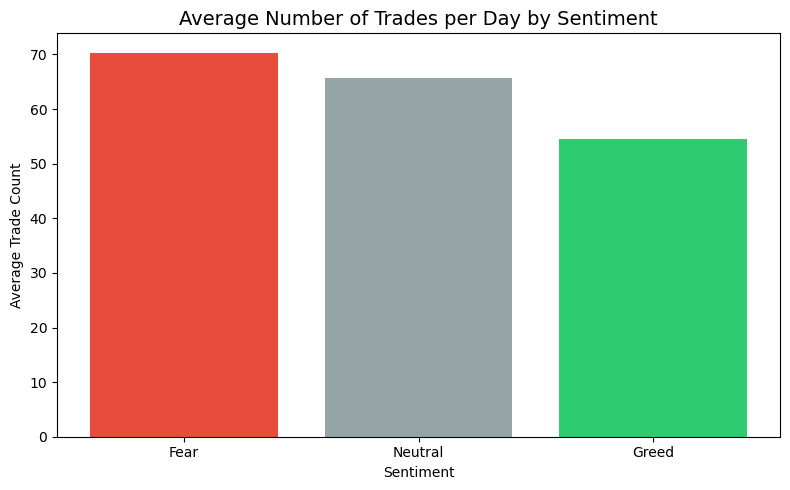

In [49]:
plt.figure(figsize=(8,5))
sentiment_trades = df_daily.groupby('sentiment_binary')['trade_count'].mean().reindex(['Fear','Neutral','Greed'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.bar(sentiment_trades.index, sentiment_trades.values, color=colors)
plt.title('Average Number of Trades per Day by Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Count')
plt.tight_layout()
plt.savefig(charts_path + 'chart_04_trade_frequency.png', dpi=150)
plt.show()

In [52]:
print(df_daily.groupby('sentiment_binary')['trade_count'].mean().reindex(['Fear','Neutral','Greed']))

sentiment_binary
Fear       70.352014
Neutral    65.695652
Greed      54.523132
Name: trade_count, dtype: float64


In [53]:
#Chart 5 — Average Position Size by Sentiment
#"Do traders bet bigger or smaller during Fear vs Greed?"

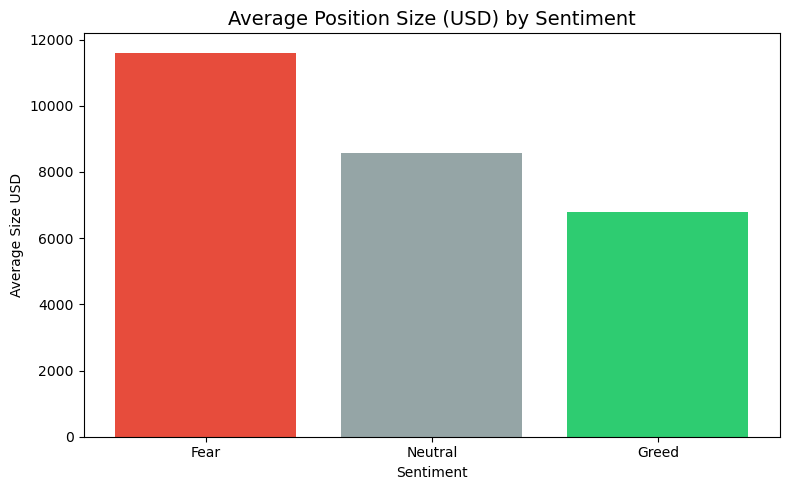

In [54]:
plt.figure(figsize=(8, 5))
sentiment_size = df_daily.groupby('sentiment_binary')['avg_size_usd'].mean().reindex(['Fear', 'Neutral', 'Greed'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.bar(sentiment_size.index, sentiment_size.values, color=colors)
plt.title('Average Position Size (USD) by Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Size USD')
plt.tight_layout()
plt.savefig(charts_path + 'chart_05_position_size.png', dpi=150)
plt.show()

In [55]:
print(sentiment_size)

sentiment_binary
Fear       11608.762064
Neutral     8561.680685
Greed       6798.067246
Name: avg_size_usd, dtype: float64


In [ ]:
#Chart 6 — Long Ratio by Sentiment
#"Do traders go more long or short depending on sentiment?"

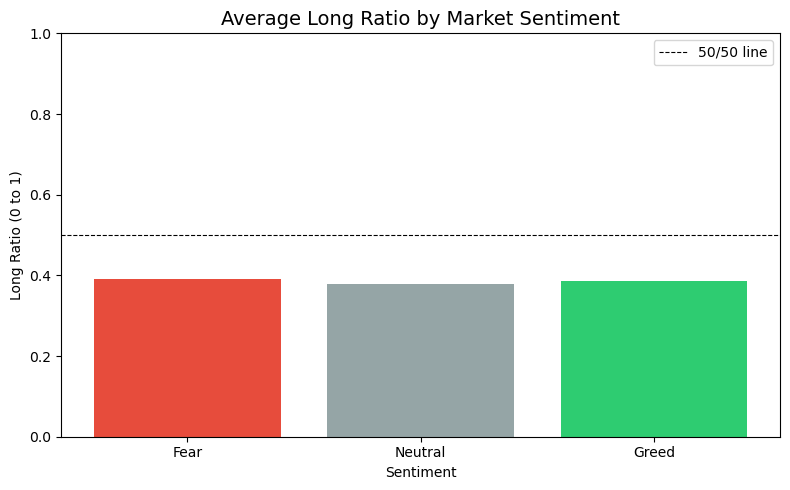

In [56]:
plt.figure(figsize=(8, 5))
sentiment_long = df_daily.groupby('sentiment_binary')['long_ratio'].mean().reindex(['Fear', 'Neutral', 'Greed'])

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
plt.bar(sentiment_long.index, sentiment_long.values, color=colors)
plt.title('Average Long Ratio by Market Sentiment', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Long Ratio (0 to 1)')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='black', linewidth=0.8, linestyle='--', label='50/50 line')
plt.legend()
plt.tight_layout()
plt.savefig(charts_path + 'chart_06_long_ratio.png', dpi=150)
plt.show()

In [57]:
print(sentiment_long)

sentiment_binary
Fear       0.390259
Neutral    0.377537
Greed      0.386800
Name: long_ratio, dtype: float64


In [63]:
#Chart 7 — PnL by Classification

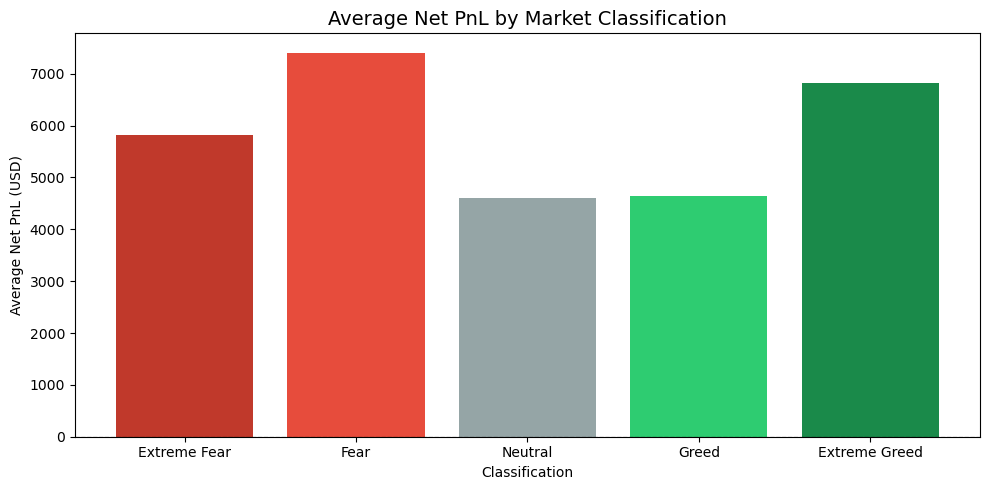

classification
Extreme Fear     5815.068080
Fear             7410.168430
Neutral          4602.001760
Greed            4637.855808
Extreme Greed    6819.571841
Name: net_pnl, dtype: float64


In [64]:
plt.figure(figsize=(10, 5))
class_pnl = df_daily.groupby('classification')['net_pnl'].mean().reindex([
    'Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'
])

colors = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#1a8a4a']
plt.bar(class_pnl.index, class_pnl.values, color=colors)
plt.title('Average Net PnL by Market Classification', fontsize=14)
plt.xlabel('Classification')
plt.ylabel('Average Net PnL (USD)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(charts_path + 'chart_07_pnl_by_classification.png', dpi=150)
plt.show()

# Print exact numbers
print(class_pnl)

In [65]:
#Chart 8 — position size by classification

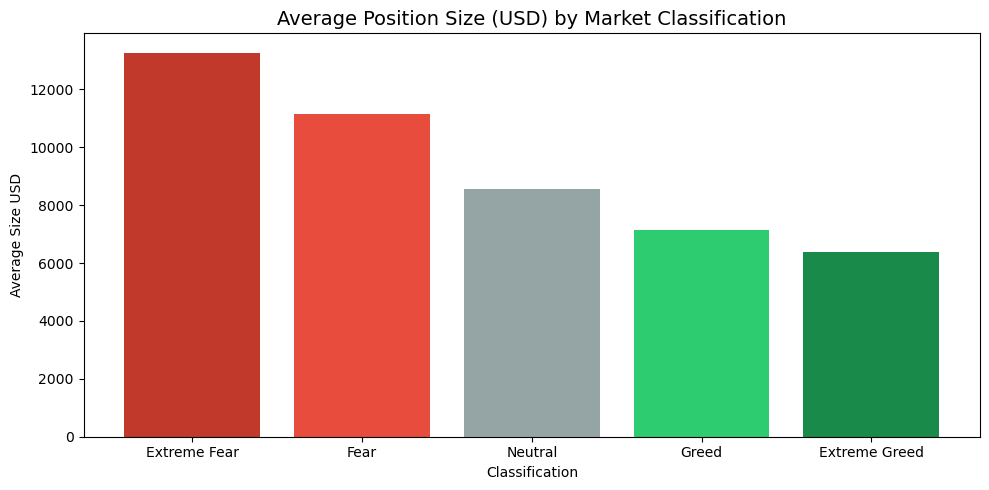

classification
Extreme Fear     13272.292096
Fear             11132.932528
Neutral           8561.680685
Greed             7152.641904
Extreme Greed     6397.827670
Name: avg_size_usd, dtype: float64


In [66]:
plt.figure(figsize=(10, 5))
class_size = df_daily.groupby('classification')['avg_size_usd'].mean().reindex([
    'Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'
])

colors = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#1a8a4a']
plt.bar(class_size.index, class_size.values, color=colors)
plt.title('Average Position Size (USD) by Market Classification', fontsize=14)
plt.xlabel('Classification')
plt.ylabel('Average Size USD')
plt.tight_layout()
plt.savefig(charts_path + 'chart_08_size_by_classification.png', dpi=150)
plt.show()

print(class_size)

In [ ]:
# Complete EDA Summary — All 8 charts

In [67]:
# 7 Key Insights Found

In [ ]:
# End of Exploratory Data Analysis